# Thermal Gap Filler and PCB Deflection Calculator

This notebook combines measured pad and PCB force–displacement data at a common force. It calculates the series response, selects the equilibrium for a specified total displacement, produces four summary plots, and creates an optional animation.

Set `USE_EXAMPLE_DATA = True` to explore the notebook immediately. Set it to `False` to load your own pad and PCB CSV files.

This model addresses the initial mechanical equilibrium only. It does not model relaxation, creep, compression set, thermal cycling, or permanent deformation.

## Input-file format

When `USE_EXAMPLE_DATA = False`, provide two CSV files. Each file must contain these columns:

```text
Disp_mm,Force_N
0.00,0.00
0.10,5.00
0.20,12.00
```

Use pad displacement in the pad file and PCB deflection in the PCB file. Both curves must cover the force range containing the desired equilibrium.

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display

## Customer inputs

In [16]:
# True: run with the built-in illustrative curves
# False: load PAD_DATA_FILE and PCB_DATA_FILE
USE_EXAMPLE_DATA = True

PAD_DATA_FILE = "pad_curve.csv"
PCB_DATA_FILE = "pcb_curve.csv"

# Assembly displacement applied across the pad and PCB in series
TARGET_TOTAL_DISPLACEMENT_MM = 0.70

# Original uncompressed pad thickness, used by the animation
PAD_ORIGINAL_THICKNESS_MM = 1.00

# Calculation resolution
COMMON_FORCE_POINTS = 500

# Animation settings
RUN_ANIMATION = True
ANIMATION_FRAMES = 60
FRAME_INTERVAL_MS = 80

# Optional GIF export
SAVE_GIF = False
GIF_FILE = "tim_pcb_side_by_side_colored.gif"
GIF_FPS = 15

## Load example data or customer files

In [17]:
if USE_EXAMPLE_DATA:

    # Illustrative gap-pad response:
    # initially soft, followed by a steep nonlinear increase
    pad_curve = pd.DataFrame({
        "Disp_mm": [
            0.00,
            0.10,
            0.20,
            0.30,
            0.40,
            0.50,
            0.60
        ],
        "Force_N": [
            0.00,
            1.50,
            4.00,
            8.00,
            15.0,
            45.0,
            180.0
        ]
    })

    # Illustrative PCB response:
    # shallow and linear, with greater displacement at higher force
    pcb_curve = pd.DataFrame({
        "Disp_mm": [
            0.00,
            0.20,
            0.40,
            0.60,
            0.80,
            1.00
        ],
        "Force_N": [
            0.00,
            10.0,
            20.0,
            30.0,
            40.0,
            50.0
        ]
    })

    print("Using built-in illustrative data.")

else:

    pad_curve = pd.read_csv(PAD_DATA_FILE)
    pcb_curve = pd.read_csv(PCB_DATA_FILE)

    print(f"Loaded pad data from: {PAD_DATA_FILE}")
    print(f"Loaded PCB data from: {PCB_DATA_FILE}")

display(pad_curve.head())
display(pcb_curve.head())



Using built-in illustrative data.


,Disp_mm,Force_N
0,0.0,0.0
1,0.1,1.5
2,0.2,4.0
3,0.3,8.0
4,0.4,15.0


,Disp_mm,Force_N
0,0.0,0.0
1,0.2,10.0
2,0.4,20.0
3,0.6,30.0
4,0.8,40.0


## Validate and prepare the measured curves

In [18]:
def prepare_curve(curve, curve_name):
    required = {"Disp_mm", "Force_N"}
    missing = required.difference(curve.columns)
    if missing:
        raise ValueError(
            f"{curve_name} is missing columns: {', '.join(sorted(missing))}"
        )

    prepared = curve[["Disp_mm", "Force_N"]].copy()
    for column in ["Disp_mm", "Force_N"]:
        prepared[column] = pd.to_numeric(prepared[column], errors="coerce")

    prepared = (
        prepared.dropna()
        .sort_values("Force_N")
        .drop_duplicates(subset="Force_N", keep="last")
        .reset_index(drop=True)
    )

    if len(prepared) < 2:
        raise ValueError(f"{curve_name} must contain at least two valid rows.")
    if (prepared[["Disp_mm", "Force_N"]] < 0).any().any():
        raise ValueError(f"{curve_name} cannot contain negative values.")
    if not prepared["Force_N"].is_monotonic_increasing:
        raise ValueError(f"{curve_name} force values must increase.")
    if not prepared["Disp_mm"].is_monotonic_increasing:
        raise ValueError(f"{curve_name} displacement values must increase with force.")

    return prepared


pad_curve = prepare_curve(pad_curve, "Pad curve")
pcb_curve = prepare_curve(pcb_curve, "PCB curve")

## Build the combined series response and solve equilibrium

In [19]:
minimum_common_force = max(
    float(pad_curve["Force_N"].min()),
    float(pcb_curve["Force_N"].min()),
)

maximum_common_force = min(
    float(pad_curve["Force_N"].max()),
    float(pcb_curve["Force_N"].max()),
)

if maximum_common_force <= minimum_common_force:
    raise ValueError("The pad and PCB curves do not have an overlapping force range.")

pad_displacement_at_force = PchipInterpolator(
    pad_curve["Force_N"], pad_curve["Disp_mm"]
)
pcb_displacement_at_force = PchipInterpolator(
    pcb_curve["Force_N"], pcb_curve["Disp_mm"]
)

common_force = np.linspace(
    minimum_common_force,
    maximum_common_force,
    COMMON_FORCE_POINTS,
)

stack = pd.DataFrame({
    "Force_N": common_force,
    "Pad_Disp_mm": pad_displacement_at_force(common_force),
    "PCB_Disp_mm": pcb_displacement_at_force(common_force),
})

stack["Total_Disp_mm"] = stack["Pad_Disp_mm"] + stack["PCB_Disp_mm"]

nonzero_total = stack["Total_Disp_mm"].replace(0, np.nan)
stack["Pad_frac"] = (stack["Pad_Disp_mm"] / nonzero_total).fillna(0.0)
stack["PCB_frac"] = (stack["PCB_Disp_mm"] / nonzero_total).fillna(0.0)

minimum_total = float(stack["Total_Disp_mm"].min())
maximum_total = float(stack["Total_Disp_mm"].max())

if not minimum_total <= TARGET_TOTAL_DISPLACEMENT_MM <= maximum_total:
    raise ValueError(
        f"TARGET_TOTAL_DISPLACEMENT_MM must be between "
        f"{minimum_total:.4f} and {maximum_total:.4f} mm for these curves."
    )

def total_displacement_error(force_value):
    return (
        float(pad_displacement_at_force(force_value))
        + float(pcb_displacement_at_force(force_value))
        - TARGET_TOTAL_DISPLACEMENT_MM
    )

equilibrium_force = brentq(
    total_displacement_error,
    minimum_common_force,
    maximum_common_force,
)

equilibrium_pad_disp = float(pad_displacement_at_force(equilibrium_force))
equilibrium_pcb_disp = float(pcb_displacement_at_force(equilibrium_force))
equilibrium_total_disp = equilibrium_pad_disp + equilibrium_pcb_disp

equilibrium = pd.Series({
    "Force_N": equilibrium_force,
    "Pad_Disp_mm": equilibrium_pad_disp,
    "PCB_Disp_mm": equilibrium_pcb_disp,
    "Total_Disp_mm": equilibrium_total_disp,
    "Pad_frac": equilibrium_pad_disp / equilibrium_total_disp,
    "PCB_frac": equilibrium_pcb_disp / equilibrium_total_disp,
})

results = pd.DataFrame({
    "Result": [
        "Equilibrium force",
        "Pad compression",
        "Compressed pad thickness",
        "PCB deflection",
        "Total imposed displacement",
    ],
    "Value": [
        equilibrium["Force_N"],
        equilibrium["Pad_Disp_mm"],
        PAD_ORIGINAL_THICKNESS_MM - equilibrium["Pad_Disp_mm"],
        equilibrium["PCB_Disp_mm"],
        equilibrium["Total_Disp_mm"],
    ],
    "Unit": ["N", "mm", "mm", "mm", "mm"],
})

results["Value"] = results["Value"].round(4)
display(results)

,Result,Value,Unit
0,Equilibrium force,15.0,N
1,Pad compression,0.4,mm
2,Compressed pad thickness,0.6,mm
3,PCB deflection,0.3,mm
4,Total imposed displacement,0.7,mm


## Static result plots

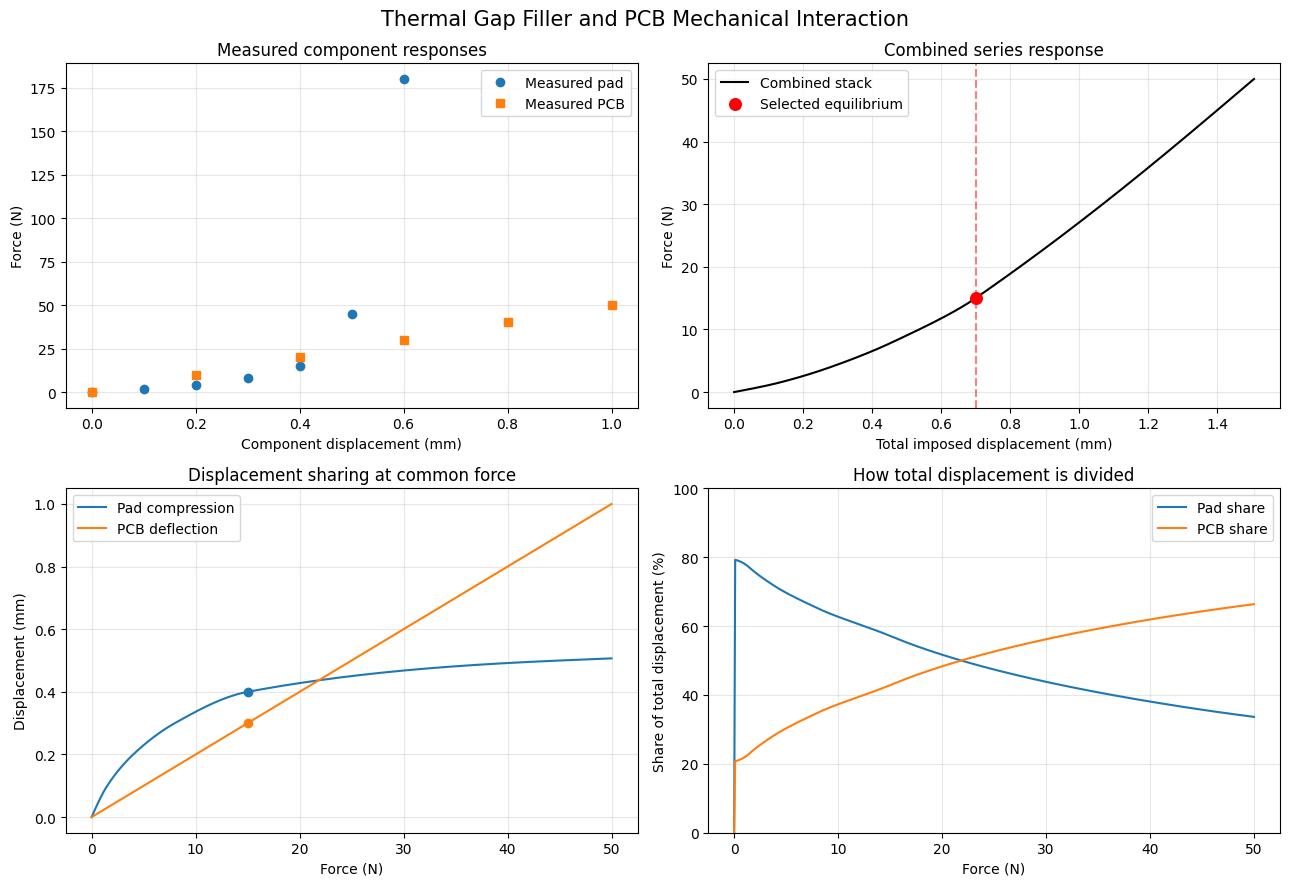

In [20]:
def plot_stack_results(stack, pad_curve, pcb_curve, equilibrium):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    ax = axes[0, 0]
    ax.plot(pad_curve["Disp_mm"], pad_curve["Force_N"], "o", label="Measured pad")
    ax.plot(pcb_curve["Disp_mm"], pcb_curve["Force_N"], "s", label="Measured PCB")
    ax.set_xlabel("Component displacement (mm)")
    ax.set_ylabel("Force (N)")
    ax.set_title("Measured component responses")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[0, 1]
    ax.plot(
        stack["Total_Disp_mm"], stack["Force_N"],
        color="black", label="Combined stack"
    )
    ax.scatter(
        equilibrium["Total_Disp_mm"], equilibrium["Force_N"],
        color="red", s=70, zorder=5, label="Selected equilibrium"
    )
    ax.axvline(
        equilibrium["Total_Disp_mm"], color="red", linestyle="--", alpha=0.5
    )
    ax.set_xlabel("Total imposed displacement (mm)")
    ax.set_ylabel("Force (N)")
    ax.set_title("Combined series response")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[1, 0]
    ax.plot(stack["Force_N"], stack["Pad_Disp_mm"], label="Pad compression")
    ax.plot(stack["Force_N"], stack["PCB_Disp_mm"], label="PCB deflection")
    ax.scatter(
        equilibrium["Force_N"], equilibrium["Pad_Disp_mm"],
        color="tab:blue", zorder=5
    )
    ax.scatter(
        equilibrium["Force_N"], equilibrium["PCB_Disp_mm"],
        color="tab:orange", zorder=5
    )
    ax.set_xlabel("Force (N)")
    ax.set_ylabel("Displacement (mm)")
    ax.set_title("Displacement sharing at common force")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[1, 1]
    ax.plot(stack["Force_N"], 100 * stack["Pad_frac"], label="Pad share")
    ax.plot(stack["Force_N"], 100 * stack["PCB_frac"], label="PCB share")
    ax.set_xlabel("Force (N)")
    ax.set_ylabel("Share of total displacement (%)")
    ax.set_ylim(0, 100)
    ax.set_title("How total displacement is divided")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.suptitle(
        "Thermal Gap Filler and PCB Mechanical Interaction",
        fontsize=15,
    )
    fig.tight_layout()
    plt.show()


plot_stack_results(stack, pad_curve, pcb_curve, equilibrium)

## Animated stack response

In [21]:
def create_stack_animation(
    stack,
    equilibrium,
    original_pad_thickness_mm,
    number_of_frames=60,
):
    valid = stack[stack["Force_N"] <= equilibrium["Force_N"]].copy()

    # Append the exact equilibrium so the animation ends at the selected result.
    equilibrium_row = pd.DataFrame([equilibrium[stack.columns]])
    valid = pd.concat([valid, equilibrium_row], ignore_index=True)
    valid = valid.sort_values("Force_N").drop_duplicates("Force_N", keep="last")

    frame_count = min(number_of_frames, len(valid))
    frame_indices = np.linspace(0, len(valid) - 1, frame_count).astype(int)
    frames = valid.iloc[frame_indices].reset_index(drop=True)

    force = frames["Force_N"].to_numpy()
    pad_disp = frames["Pad_Disp_mm"].to_numpy()
    pcb_disp = frames["PCB_Disp_mm"].to_numpy()
    total_disp = frames["Total_Disp_mm"].to_numpy()

    pad_width = 2.0
    pcb_half_span = 5.0
    heatsink_width = 6.0
    heatsink_height = 0.30

    fig, (ax_anim, ax_graph) = plt.subplots(
        1,
        2,
        figsize=(14, 6),
        gridspec_kw={"width_ratios": [1.5, 1]},
    )

    def draw_frame(i):
        ax_anim.clear()
        ax_graph.clear()

        current_force = force[i]
        current_pad_disp = pad_disp[i]
        current_pcb_disp = pcb_disp[i]
        current_total_disp = total_disp[i]

        # Left panel: physical stack
        ax_anim.set_xlim(-6, 6)
        ax_anim.set_ylim(-2, 3)
        ax_anim.set_aspect("equal")
        ax_anim.set_title(
            f"Stack Deflection\nForce = {current_force:.1f} N",
            fontsize=15,
        )

        x_pcb = np.linspace(-pcb_half_span, pcb_half_span, 300)
        pcb_y = -current_pcb_disp * (1 - (x_pcb / pcb_half_span) ** 2)
        ax_anim.plot(x_pcb, pcb_y, linewidth=6, color="green", label="PCB")

        pad_thickness = max(
            original_pad_thickness_mm - current_pad_disp,
            0.05,
        )
        pad_bottom = -current_pcb_disp
        pad_top = pad_bottom + pad_thickness

        ax_anim.add_patch(plt.Rectangle(
            (-pad_width / 2, pad_bottom),
            pad_width,
            pad_thickness,
            facecolor="gray",
            edgecolor="black",
            alpha=0.75,
            label="Pad",
        ))
        ax_anim.add_patch(plt.Rectangle(
            (-heatsink_width / 2, pad_top),
            heatsink_width,
            heatsink_height,
            facecolor="lightgray",
            edgecolor="black",
            alpha=0.90,
            label="Heat sink",
        ))

        ax_anim.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.6)
        ax_anim.text(0, pad_top + heatsink_height / 2, "Heat Sink", ha="center", va="center")
        ax_anim.text(0, pad_bottom + pad_thickness / 2, "Pad", ha="center", va="center")
        ax_anim.text(0, pad_bottom - 0.22, "PCB", ha="center", va="top")
        ax_anim.set_xlabel("Position across PCB")
        ax_anim.set_ylabel("Vertical position (mm)")
        ax_anim.grid(True, alpha=0.3)
        ax_anim.legend(loc="upper right")

        # Right panel: the same three responses used in the calculation
        ax_graph.plot(pad_disp, force, color="gray", linewidth=2, label="Pad only")
        ax_graph.plot(pcb_disp, force, color="green", linewidth=2, label="PCB only")
        ax_graph.plot(total_disp, force, color="blue", linewidth=2, label="Combined stack")

        ax_graph.plot(current_pad_disp, current_force, "o", color="gray", markersize=8)
        ax_graph.plot(current_pcb_disp, current_force, "o", color="green", markersize=8)
        ax_graph.plot(current_total_disp, current_force, "o", color="blue", markersize=9)

        max_total_disp = max(float(np.max(total_disp)), 0.01)
        max_force = max(float(np.max(force)), 0.01)
        ax_graph.set_xlim(0, max_total_disp * 1.10)
        ax_graph.set_ylim(0, max_force * 1.10)
        ax_graph.set_title("Force vs. Displacement")
        ax_graph.set_xlabel("Displacement (mm)")
        ax_graph.set_ylabel("Force (N)")
        ax_graph.text(
            0.05 * max_total_disp,
            0.92 * max_force,
            f"Pad = {current_pad_disp:.3f} mm\n"
            f"PCB = {current_pcb_disp:.3f} mm\n"
            f"Total = {current_total_disp:.3f} mm",
            va="top",
            bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
        )
        ax_graph.grid(True, alpha=0.3)
        ax_graph.legend(loc="lower right")
        fig.tight_layout()

    animation = FuncAnimation(
        fig,
        draw_frame,
        frames=len(frames),
        interval=FRAME_INTERVAL_MS,
        repeat=True,
    )
    plt.close(fig)
    return animation


if RUN_ANIMATION:
    stack_animation = create_stack_animation(
        stack,
        equilibrium,
        PAD_ORIGINAL_THICKNESS_MM,
        ANIMATION_FRAMES,
    )

    if SAVE_GIF:
        stack_animation.save(GIF_FILE, writer=PillowWriter(fps=GIF_FPS))
        print("GIF saved to:")
        print(os.path.abspath(GIF_FILE))

    display(HTML(stack_animation.to_jshtml()))
else:
    print("Animation is off. Set RUN_ANIMATION = True to display it.")

## Assumptions and limitations

- The pad curve corresponds to the loading rate represented by the measurement.
- Pad and PCB displacements are added at a common force because they act in series.
- PCHIP interpolation is used only within the overlapping measured force range.
- The PCB input may be linear or measured; the notebook does not require linearity.
- Results are preliminary estimates and should be verified using the actual assembly.
- Relaxation, creep, compression set, thermal cycling, and permanent deformation are not modeled.